# LOFO

In [ ]:
import sage

from itertools import combinations
import numpy as np
import pandas as pd
import xgboost
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

**Data and model**

In [ ]:
df = sage.datasets.bike()
features = df.columns.tolist()[:-3]
target = df.columns.tolist()[-1]

In [ ]:
print("Features:", features)
print("Target:", target)

Features: ['Year', 'Month', 'Day', 'Hour', 'Season', 'Holiday', 'Workingday', 'Weather', 'Temp', 'Atemp', 'Humidity', 'Windspeed']
Target: Count


In [ ]:
# Split data, with total count serving as regression target
train, test = train_test_split(df, test_size=int(0.1 * len(df.values)), random_state=123)
train, val = train_test_split(train, test_size=int(0.1 * len(df.values)), random_state=123)

y_train = train[[target]]
y_bkg = val[[target]]
y_test = test[[target]]
x_train = train[features]
x_bkg = val[features]
x_test = test[features]

In [ ]:
model = xgboost.XGBRegressor()
model.fit(x_train, y_train);

In [ ]:
def mse(prediction, target):
    return np.mean((prediction - target)**2).item()

In [ ]:
# Calculate performance
base_mse = np.mean((np.mean(y_train) - y_test) ** 2)
full_mse = mse(model.predict(x_test), y_test.to_numpy().flatten())

print("Base rate MSE = {:.2f}".format(base_mse))
print("Model MSE = {:.2f}".format(full_mse))

Base rate MSE = 31591.23
Model MSE = 1878.77


### LOFO

In [ ]:
def lofo(model, features, train_df, y_train, test_df, y_test, loss):
    losses = {}
    lofos_ratio = {}
    lofos_diff = {}

    for i, feature in enumerate(features):
        _x_train = train_df[i:] + train_df[:i+1]
        _x_test = test_df[i:] + test_df[:i+1]

        _model = xgboost.XGBRegressor()
        _model.fit(_x_train, y_train)

        #get the loss for the subset and store it
        y_pred = _model.predict(_x_test)
        loss_subset = mean_squared_error(y_pred, y_test)
        losses[feature] = loss_subset
    for i, features in enumerate(features):
        # calculate the lofo as a ratio or difference (or both)
        lofos_ratio_subset = loss/ losses[features]
        lofos_ratio[features] = lofos_ratio_subset
        lofos_diff_subset = loss - losses[features]
        lofos_diff[features] = lofos_diff_subset
    return lofos_ratio, lofos_diff

In [ ]:
def lofo(model, features, train_df, y_train, test_df, y_test, loss):
    losses = {}
    lofos_ratio = {}
    lofos_diff = {}

    for _features in combinations(features, len(features)-1):
        _excluded = list(set(features) - set(_features))[0]
        _features = list(_features)
        _x_train = train_df[_features]
        _x_test = test_df[_features]

        _model = xgboost.XGBRegressor()
        _model.fit(_x_train, y_train);

        _loss = loss(_model.predict(_x_test), y_test.to_numpy().flatten())

        losses[_excluded] = _loss

    for _feature in features:
        lofos_ratio[_feature] = losses[_feature]/full_mse
        lofos_diff[_feature] = losses[_feature]-full_mse

    return lofos_ratio, lofos_diff

In [ ]:
lofos_ratio, lofos_diff = lofo(model, features, train, y_train, test, y_test, mse)

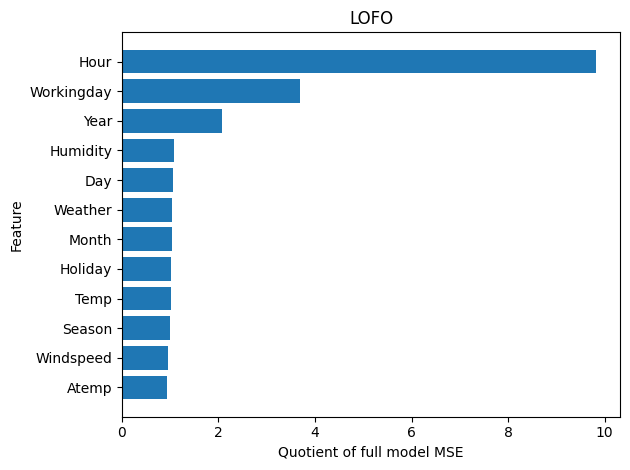

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_ratio.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Quotient of full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

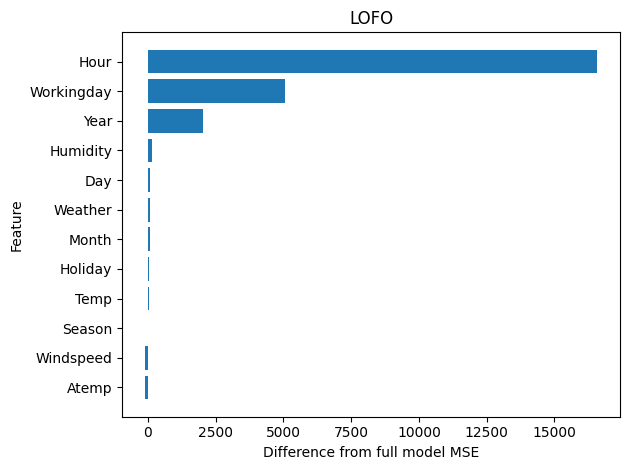

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_diff.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Difference from full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

In [ ]:
train_without = train.drop("Season", axis = 1)
test_without = test.drop("Season", axis = 1)

# Create a new features list that excludes 'Season'
features_without_season = [f for f in features if f != "Season"]

# Call lofo with the updated features list
lofos_ratio, lofos_diff = lofo(model, features_without_season, train_without, y_train, test_without, y_test, mse)

### LOFO without correlated features

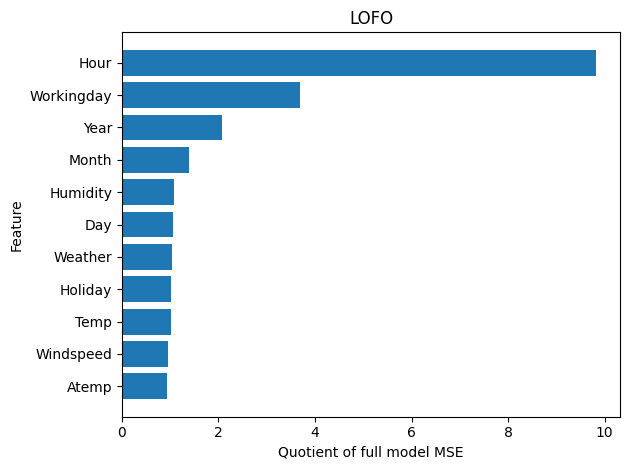

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_ratio.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Quotient of full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

In [ ]:
train_without = train.drop("Month", axis = 1)
test_without = test.drop("Month", axis = 1)

# Create a new features list that excludes 'Season'
features_without_month = [f for f in features if f != "Month"]

# Call lofo with the updated features list
lofos_ratio, lofos_diff = lofo(model, features_without_month, train_without, y_train, test_without, y_test, mse)

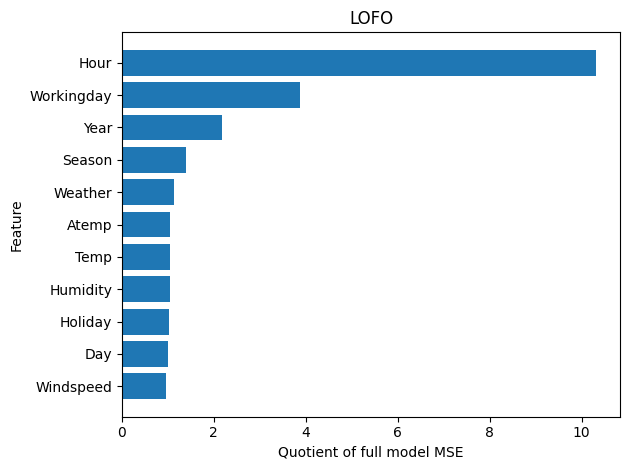

In [ ]:
# Create horizontal bar plot from sorted values
sorted_items = sorted(lofos_ratio.items(), key=lambda x: x[1])
keys, values = zip(*sorted_items)

plt.barh(range(len(keys)), values)
plt.yticks(range(len(keys)), keys)
plt.xlabel('Quotient of full model MSE')
plt.ylabel('Feature')
plt.title('LOFO')
plt.tight_layout()
plt.show()

#### Comment
This comment is about performance mpodel no predictionWe can say there the rank of Month become more important when we delete Season to use LOFO. The same thing for  Season  when we  delete Month. That mean because these features are correled , LOFO don't find the important of them when both ois present. But
the removing of one helps LOFO to get the really importance.